# Understanding np.linalg.norm

`np.linalg.norm` computes the **norm** (magnitude/length) of a vector or matrix.

## What is a Norm?
A norm measures the "size" or "length" of a vector. The most common is the **Euclidean norm** (L2 norm), which is the straight-line distance from origin to the point.

## Common Norm Types:

1. **L2 Norm (Euclidean norm)** - Default: `np.linalg.norm(x)`
   - Formula: `√(x₁² + x₂² + ... + xₙ²)`
   - This is the Euclidean distance (straight-line distance)
   - Example: `norm([3, 4]) = √(3² + 4²) = √25 = 5`

2. **L1 Norm (Manhattan norm)**: `np.linalg.norm(x, ord=1)`
   - Formula: `|x₁| + |x₂| + ... + |xₙ|`
   - Sum of absolute values

3. **Frobenius norm** (for matrices): `np.linalg.norm(matrix)`
   - Square root of sum of squares of all elements

## In KMeans Context:

When computing distances between a data point and centroids:
- `X[i] - centroids` gives the difference vectors
- `np.linalg.norm(X[i] - centroids, axis=1)` computes Euclidean distance for each centroid
- This tells us how far each centroid is from the data point


In [4]:
# GOAL : IMPLEMENT KMEANS CLUSTERING FROM SCRATCH
# TRAINING DATA : X (n_samples, n_features)
# K : number of clusters
# MAX_ITER : maximum number of iterations
# TOL : tolerance for convergence
# RANDOM_STATE : random seed

import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

class KMeans:
    def __init__(self, k: int, max_iters: int = 100, tol: float = 1e-4, random_seed: int = None):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_seed = random_seed
        self.centroids = None
        self.labels = None
    
    def initialize_centroids(self, X: np.ndarray) -> np.ndarray:
        """
        Initialize centroids randomly from the training data
        
        Args:
            X: Training data (n_samples, n_features)
        Returns:
            List of initial centroids (each centroid is a list of features)
        """
        n_samples, n_features = X.shape
        np.random.seed(self.random_seed)
        indices = np.random.choice(range(n_samples), size=self.k, replace=False)
        return X[indices]
    
    def assign_clusters(self, X: np.ndarray, centroids: np.ndarray) -> np.ndarray:
        """
        Assign each data point to the nearest centroid
        
        Args:
            X: Training data (n_samples, n_features)
            centroids: List of centroids (each centroid is a list of features)
        Returns:
            List of cluster labels (each label is an integer)
        """
        n_samples, n_features = X.shape
        labels = np.zeros(n_samples, dtype=int)
        # Compute Euclidean distance from data point X[i] to each centroid
        # X[i] - centroids: shape (k, n_features) - difference vectors
        # axis=1: compute norm along each row (for each centroid)
        distances = ((X[:,None, :] - centroids[None,:,:])**2).sum(axis=2)
        # Assign to nearest centroid
        labels = np.argmin(distances, axis=1)
        return labels

    def update_centroids(self, X: np.ndarray, labels: np.ndarray) -> np.ndarray:
        """
        Update centroids to the mean of points in their cluster
        
        Args:
            X: Training data (n_samples, n_features)
            labels: List of cluster labels (each label is an integer)
        Returns:
            Updated centroids (each centroid is a list of features)
        """
        n_samples, n_features = X.shape
        empty_flag = False
        centroids = np.zeros((self.k, n_features))  
        for i in range(self.k):
            # Get all points in cluster i
            cluster_points = X[labels == i]
            if cluster_points.size == 0:
                empty_flag = True
                centroids[i] = X[np.random.choice(range(n_samples))]
            else:
                # Compute mean of points in cluster i
                centroids[i] = cluster_points.mean(axis=0)
        return centroids

    def convergence_check(self, old_centroids: np.ndarray, new_centroids: np.ndarray) -> bool:
        """
        Check if centroids have converged
        
        Args:
            old_centroids: Previous centroids (n_clusters, n_features)
            new_centroids: New centroids (n_clusters, n_features)
        Returns:
            True if centroids have converged, False otherwise
        """
        max_diff = np.max(np.abs(old_centroids - new_centroids))    
        return max_diff < self.tol  
            
    def fit(self, X: np.ndarray) -> np.ndarray:
        """
        Fit KMeans model to training data
        
        Args:
            X: Training data (n_samples, n_features)
        Returns:
            List of cluster labels (each label is an integer)
        """
        n_samples, n_features = X.shape
        self.centroids = self.initialize_centroids(X)
        for _ in range(self.max_iters):
            old_centroids = self.centroids.copy()
            labels = self.assign_clusters(X, self.centroids)
            self.centroids = self.update_centroids(X, labels)
            if self.convergence_check(old_centroids, self.centroids):
                break
        return labels
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict cluster labels for new data

        Args:
            X: New data (n_samples, n_features)
        Returns:
            List of cluster labels (each label is an integer)
        """
        return self.assign_clusters(X, self.centroids)
    
    def plot_clusters(self, X: np.ndarray, labels: np.ndarray) -> None:
        """
        Plot the clusters
        
        Args:
            X: Training data (n_samples, n_features)    
            labels: List of cluster labels (each label is an integer)
        """
        plt.figure(figsize=(10, 6))
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
        colors = plt.cm.viridis(labels / self.k)
        for i, centroid in enumerate(self.centroids):
            plt.scatter(centroid[0], centroid[1], c=colors[i], s=200, marker='X')
            plt.text(centroid[0], centroid[1], f'Centroid {i}', fontsize=12, ha='center', va='center')
        plt.title('KMeans Clustering')
        plt.show()


    



/var/folders/60/6__24x49581_f2q0n12z3wd40000gn/T/ipykernel_23843/2748103129.py:134: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(centroid[0], centroid[1], c=colors[i], s=200, marker='X')


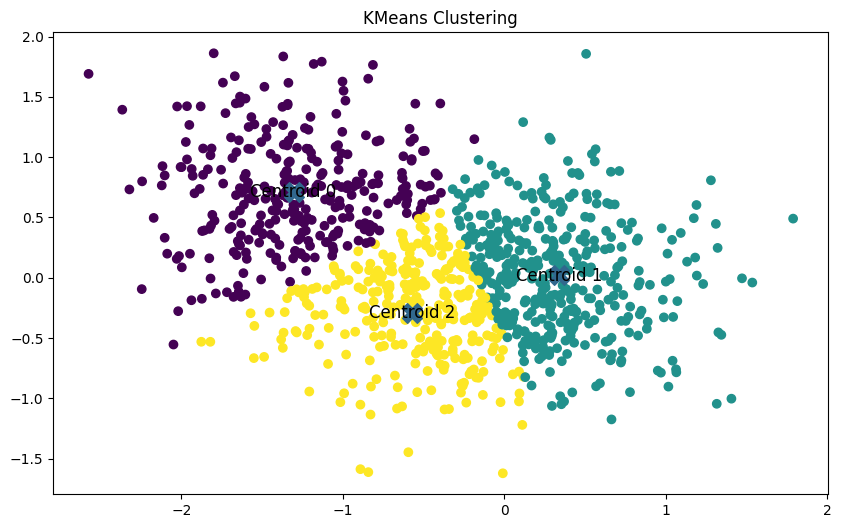

In [5]:
def kmeas_data_generator(n_samples: int, n_features: int, n_clusters: int, random_state: int = None) -> np.ndarray:
    """
    Generate synthetic data for KMeans clustering
    
    Args:
        n_samples: Number of samples to generate
        n_features: Number of features for each sample
        n_clusters: Number of clusters
        random_state: Random seed
    Returns:
        Synthetic data (n_samples, n_features)
    """
    np.random.seed(random_state)
    n_samples_per_cluster = n_samples // n_clusters
    X = np.zeros((n_samples, n_features))
    for i in range(n_clusters):
        # Generate random center for cluster i
        center = np.random.randn(n_features) * 0.5
        X[i*n_samples_per_cluster:(i+1)*n_samples_per_cluster] = center + np.random.randn(n_samples_per_cluster, n_features) * 0.5
    return X

def kmeans_clustering_example():
    # Generate synthetic data
    X = kmeas_data_generator(n_samples=1000, n_features=2, n_clusters=3, random_state=42)

    # Initialize KMeans
    kmeans = KMeans(k=3, max_iters=100, tol=1e-4, random_seed=42)

    # Fit the model
    labels = kmeans.fit(X)

    # Plot the results
    kmeans.plot_clusters(X, labels)

if __name__ == "__main__":
    kmeans_clustering_example()

